# 1. Setup and import

In [1]:
%load_ext autoreload
%autoreload 2

### Import libraries and dependencies

In [2]:
!pip install pywaffle
!pip install --upgrade kagglehub -q
!pip install scikit-plot -q
!pip install phik
!pip install imblearn
!pip install seaborn
!pip install category_encoders
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


...


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Import from custom modules
from src.data_loader import load_stroke_data
from src.preprocessing import clean_base_data, impute_bmi_with_rf, discretize_features, apply_smoteenn
from src.models import build_stacking_model, build_voting_model
from src.evaluation import evaluate_and_plot

# Figure styling
sns.set_style("white")
colors = ['#0D1164', '#640D5F', '#EA2264', '#F78D60']
import warnings
warnings.filterwarnings('ignore')

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load dataset

In [4]:
# Load dataset using custom loader
df = load_stroke_data()
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# 2. Exploratory Data Analysis

### Target Variable

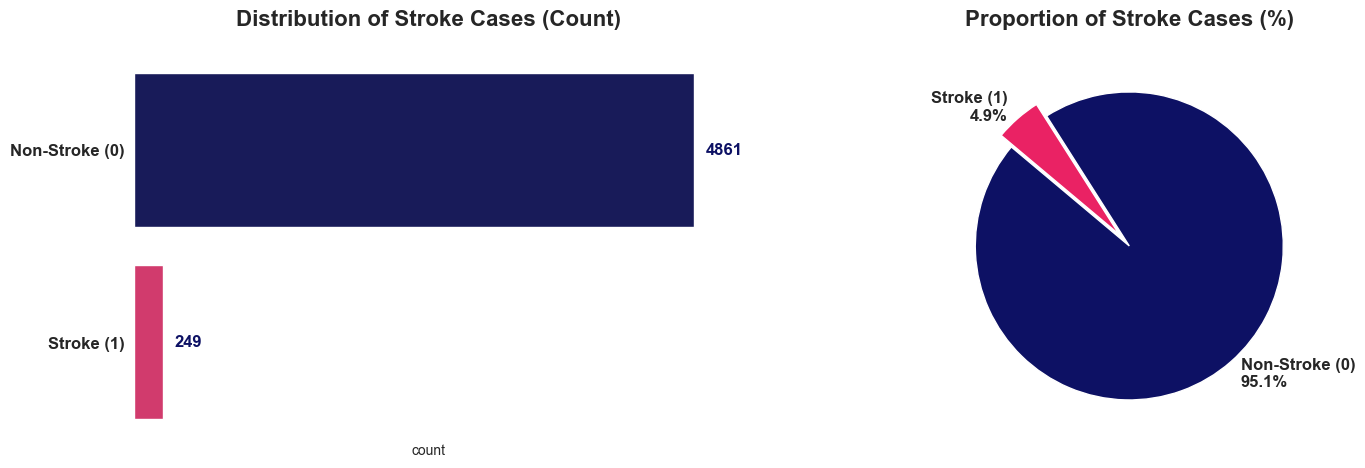

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [1.2, 1]})
plt.subplots_adjust(wspace=0.3)

# 1. Countplot
sns.countplot(data=df, y='stroke', palette=[colors[0], colors[2]], ax=ax[0])
ax[0].set_title('Distribution of Stroke Cases (Count)', fontsize=16, fontweight='bold', pad=20)
ax[0].set_yticklabels(['Non-Stroke (0)', 'Stroke (1)'], fontsize=12, fontweight='bold')
sns.despine(ax=ax[0], left=True, bottom=True)
ax[0].set_xticks([])
ax[0].set_ylabel('')

for p in ax[0].patches:
    width = p.get_width()
    ax[0].annotate(f'{int(width)}', (width + 100, p.get_y() + p.get_height() / 2.),
                   ha='left', va='center', fontsize=12, fontweight='bold', color=colors[0])

# 2. Pie Chart
stroke_counts = df['stroke'].value_counts()
total = sum(stroke_counts)
labels_with_perc = [f"Non-Stroke (0)\n{(stroke_counts[0]/total)*100:.1f}%", f"Stroke (1)\n{(stroke_counts[1]/total)*100:.1f}%"]

ax[1].pie(stroke_counts, labels=labels_with_perc, startangle=140, colors=[colors[0], colors[2]],
          explode=(0, 0.1), shadow=False, textprops={'fontsize': 12, 'fontweight': 'bold'})
ax[1].set_title('Proportion of Stroke Cases (%)', fontsize=16, fontweight='bold', pad=20)
plt.show()

### Numerical features

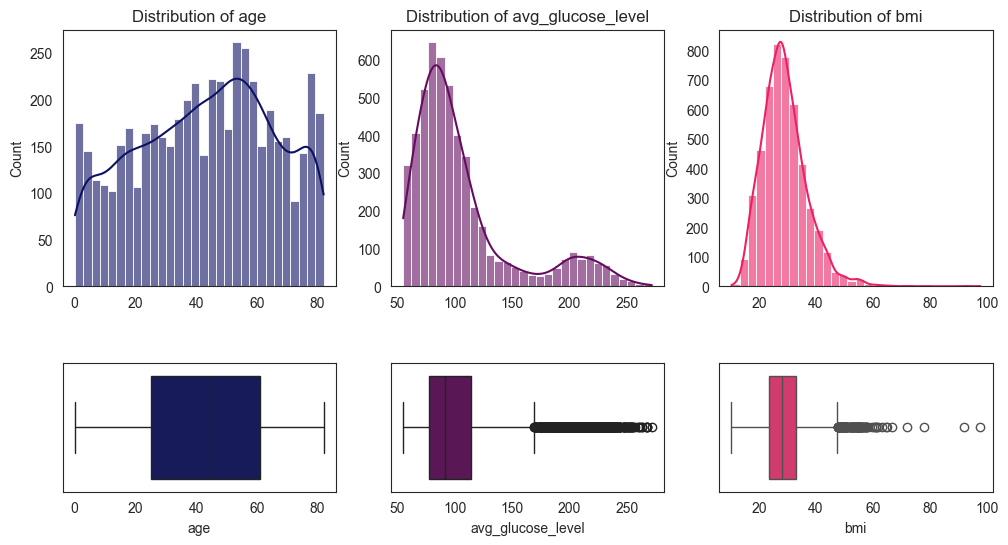

In [6]:
num_features = ['age', 'avg_glucose_level', 'bmi']

fig, axes = plt.subplots(2, 3, figsize=(12, 6), gridspec_kw={'height_ratios': [2, 1]})
plt.subplots_adjust(hspace=0.4)

for i, col in enumerate(num_features):
    # Histogram + KDE
    sns.histplot(df[col], bins=30, kde=True, ax=axes[0, i], color=colors[i], alpha=0.6)
    axes[0, i].set_title(f'Distribution of {col}', fontsize=12)
    axes[0, i].set_xlabel('')
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1, i], color=colors[i])
    axes[1, i].set_xlabel(col)

plt.show()

### Categorical features

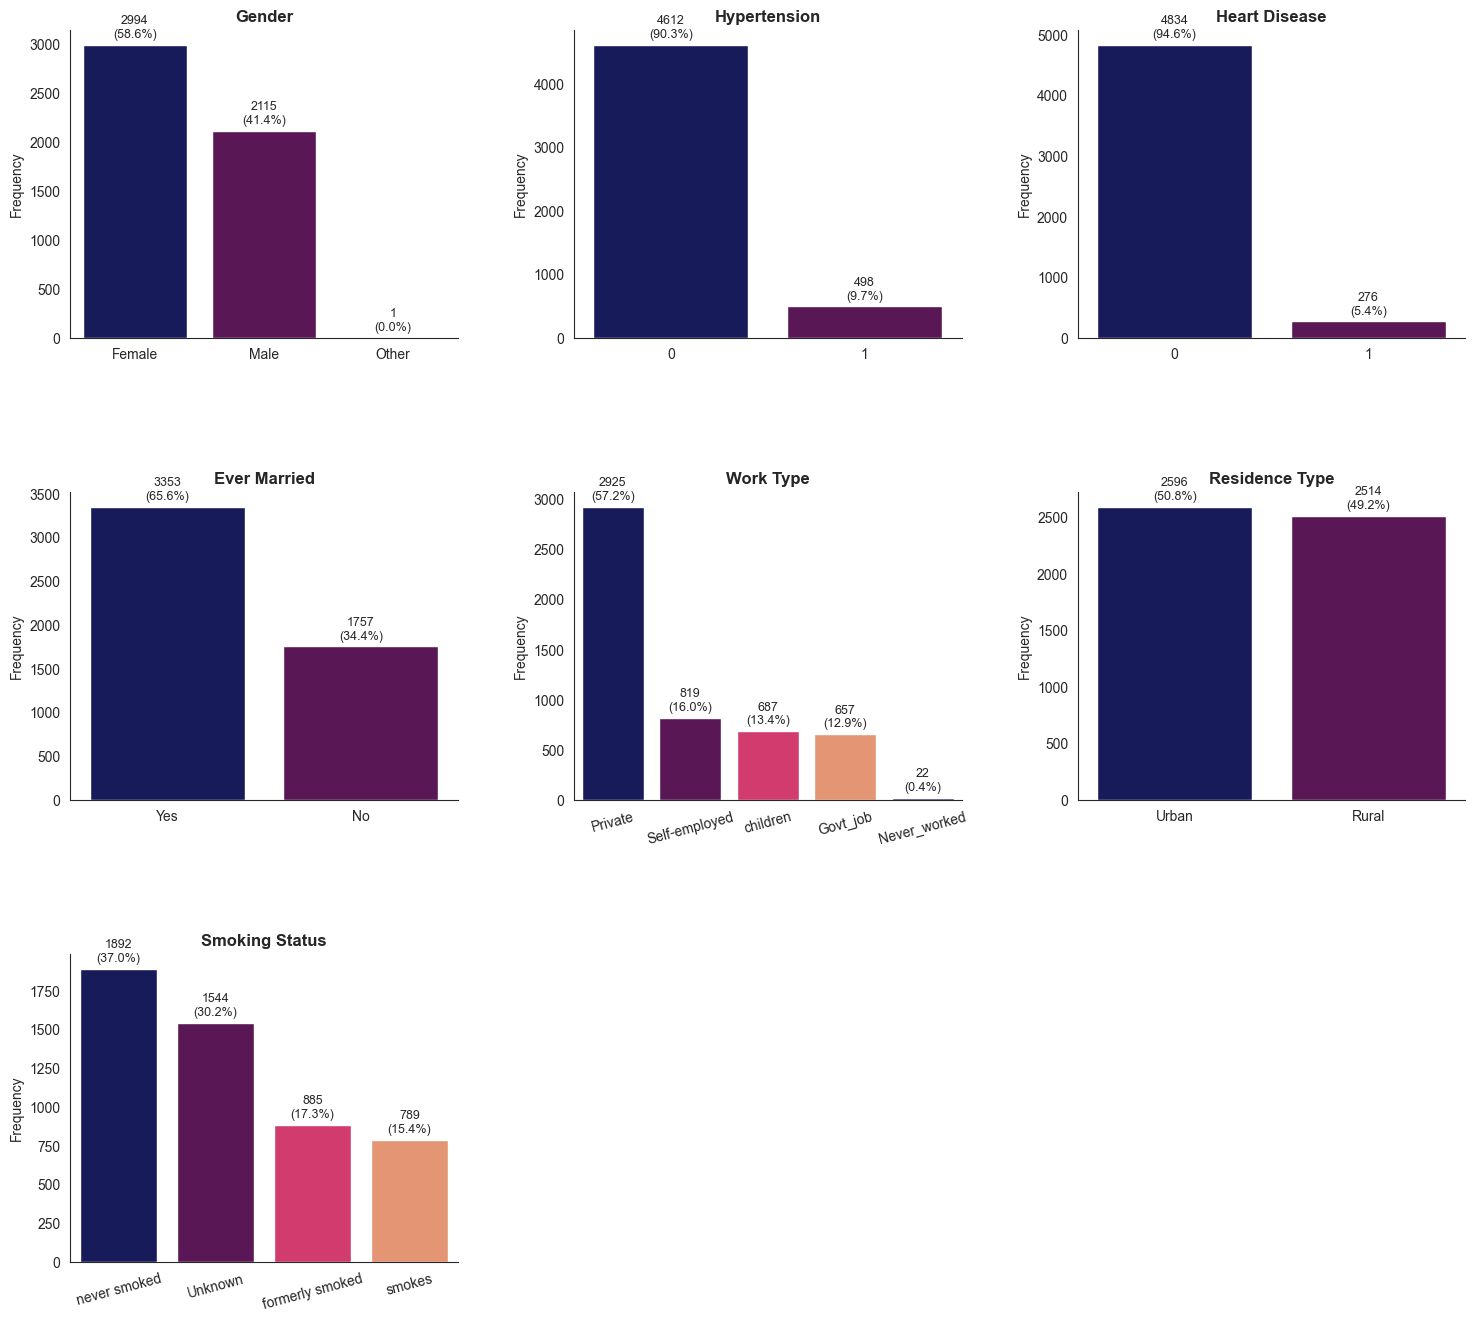

In [7]:
cat_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 16))
plt.subplots_adjust(hspace=0.5, wspace=0.3)
axes[2, 1].axis('off'); axes[2, 2].axis('off') # Hide empty subplots

for i, col in enumerate(cat_cols):
    row, col_idx = i // 3, i % 3
    curr_ax = axes[row, col_idx]
    
    counts = df[col].value_counts()
    sns.countplot(data=df, x=col, palette=colors, ax=curr_ax, order=counts.index)
    
    total_valid = len(df[col].dropna())
    for container in curr_ax.containers:
        labels = [f'{int(v.get_height())}\n({v.get_height()/total_valid*100:.1f}%)' for v in container]
        curr_ax.bar_label(container, labels=labels, padding=3, fontsize=9)
        
    curr_ax.set_title(f'{col.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    curr_ax.set_xlabel(''); curr_ax.set_ylabel('Frequency')
    if col in ['work_type', 'smoking_status']:
        curr_ax.tick_params(axis='x', rotation=15)
        
sns.despine()
plt.show()

### Correlation & Multicollinearity

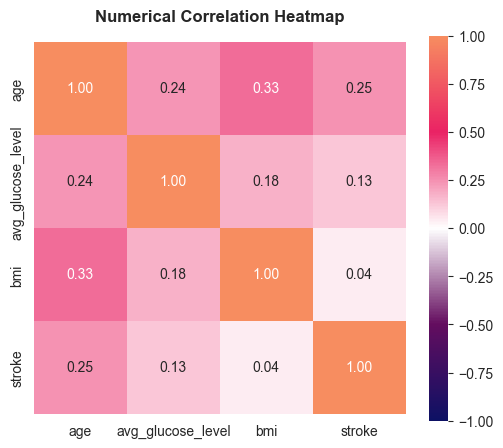


--- Multicollinearity Diagnostic Results (VIF) ---
             Feature  VIF_Score
1                age   1.167676
3                bmi   1.137775
2  avg_glucose_level   1.070868


In [8]:
# Correlation Heatmap
custom_cmap = LinearSegmentedColormap.from_list("", ['#0D1164','#640D5F','white','#EA2264','#F78D60'])
numeric_df = df[['age', 'avg_glucose_level', 'bmi', 'stroke']]

plt.figure(figsize=(6, 5))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap=custom_cmap, vmin=-1, vmax=1, square=True)
plt.title("Numerical Correlation Heatmap", fontsize=12, fontweight='bold', pad=15)
plt.show()

# VIF Calculation
vif_temp_df = df[num_features].dropna()
X_vif = add_constant(vif_temp_df)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF_Score"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print("\n--- Multicollinearity Diagnostic Results (VIF) ---")
print(vif_data[vif_data['Feature'] != 'const'].sort_values(by="VIF_Score", ascending=False))

# 3. Pipeline

### Preprocessing

In [9]:
# Clean, separate target, and impute
df_clean = clean_base_data(df)
y = df_clean['stroke']
X = df_clean.drop(columns=['stroke'])

print("Imputing missing BMI values with Random Forest...")
X = impute_bmi_with_rf(X)
X = discretize_features(X)
print("Preprocessing complete.")

Imputing missing BMI values with Random Forest...
Preprocessing complete.


### Splitting, Encoding, and Balancing (SMOTEENN)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

categorical_cols = ['gender', 'ever_married', 'Residence_type', 'work_type', 'smoking_status', 'bmi_cat', 'age_cat', 'glucose_cat']
le = LabelEncoder()
for col in categorical_cols:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

print(f"Original Training Class Distribution: {np.bincount(y_train)}")
all_cat_cols = categorical_cols + ["hypertension", "heart_disease"]
X_train_res, y_train_res = apply_smoteenn(X_train, y_train, all_cat_cols)
print(f"Resampled Training Class Distribution: {np.bincount(y_train_res)}")

Original Training Class Distribution: [3888  199]
Resampled Training Class Distribution: [2830 3428]


### Model Training & Evaluation

With SMOTEENN data

Training Stacking Classifier...

--- STACKING CLASSIFIER (THRESHOLD 0.45) RESULTS ---
Recall (Stroke): 0.54
Overall Accuracy: 0.85

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.87      0.92       972
           1       0.17      0.54      0.26        50

    accuracy                           0.85      1022
   macro avg       0.57      0.70      0.59      1022
weighted avg       0.93      0.85      0.88      1022



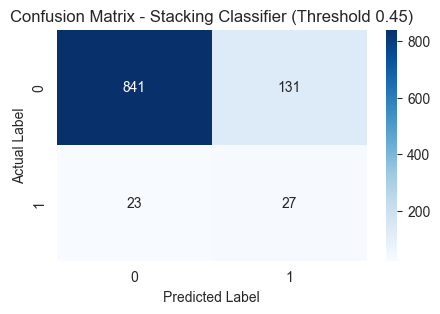

Training Voting Classifier...

--- VOTING CLASSIFIER (THRESHOLD 0.45) RESULTS ---
Recall (Stroke): 0.66
Overall Accuracy: 0.78

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.78      0.87       972
           1       0.14      0.66      0.22        50

    accuracy                           0.78      1022
   macro avg       0.56      0.72      0.55      1022
weighted avg       0.94      0.78      0.84      1022



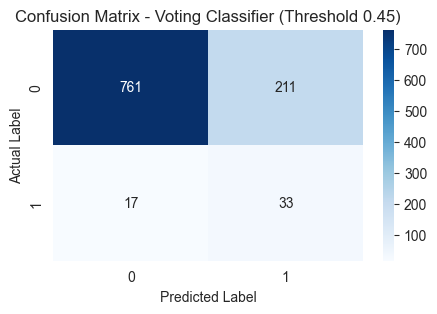

In [11]:
# Train and Evaluate Stacking Classifier
print("Training Stacking Classifier...")
stacking_model = build_stacking_model()
stacking_model.fit(X_train_res, y_train_res)
evaluate_and_plot(stacking_model, X_test, y_test, model_name="Stacking Classifier", threshold=0.45)

# Train and Evaluate Voting Classifier
print("Training Voting Classifier...")
voting_model = build_voting_model() 
voting_model.fit(X_train_res, y_train_res)
evaluate_and_plot(voting_model, X_test, y_test, model_name="Voting Classifier", threshold=0.45)

### MLP Model

Number of input features: 13
Number of classes: 2
Calculated Hidden Nodes (WEKA 'a'): 7


--- MULTILAYER PERCEPTRON (THRESHOLD 0.45) RESULTS ---
Recall (Stroke): 0.90
Overall Accuracy: 0.47

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.45      0.61       972
           1       0.08      0.90      0.14        50

    accuracy                           0.47      1022
   macro avg       0.53      0.67      0.38      1022
weighted avg       0.94      0.47      0.59      1022



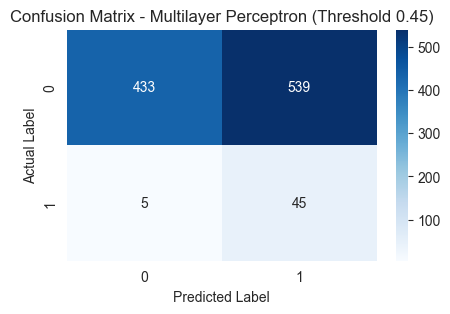

In [12]:
from src.models import build_weka_mlp

# 1. Calculate 'a' dynamically based on our SMOTEENN balanced data
n_features = X_train_res.shape[1]
n_classes = len(np.unique(y_train_res))

print(f"Number of input features: {n_features}")
print(f"Number of classes: {n_classes}")
print(f"Calculated Hidden Nodes (WEKA 'a'): {int((n_features + n_classes) / 2)}\n")

# 2. Build and Train the MLP
mlp_model = build_weka_mlp(n_features, n_classes)
mlp_model.fit(X_train_res, y_train_res)

# 3. Evaluate
evaluate_and_plot(mlp_model, X_test, y_test, model_name="Multilayer Perceptron", threshold=0.45)

### Random Forest

Training Random Forest...

--- RANDOM FOREST (THRESHOLD 0.45) RESULTS ---
Recall (Stroke): 0.60
Overall Accuracy: 0.80

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.81      0.89       972
           1       0.14      0.60      0.23        50

    accuracy                           0.80      1022
   macro avg       0.56      0.71      0.56      1022
weighted avg       0.93      0.80      0.85      1022



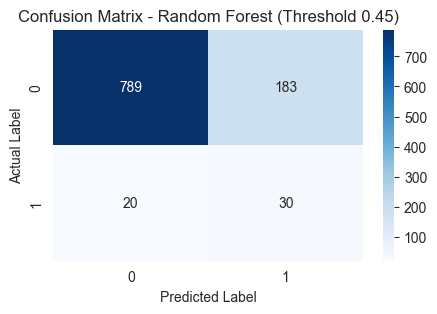

In [13]:
from sklearn.ensemble import RandomForestClassifier

# Train and Evaluate Random Forest
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_res, y_train_res)
evaluate_and_plot(rf_model, X_test, y_test, model_name="Random Forest", threshold=0.45)

### XGBoost

Training XGBoost...

--- XGBOOST (THRESHOLD 0.45) RESULTS ---
Recall (Stroke): 0.60
Overall Accuracy: 0.81

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.82      0.89       972
           1       0.14      0.60      0.23        50

    accuracy                           0.81      1022
   macro avg       0.56      0.71      0.56      1022
weighted avg       0.93      0.81      0.86      1022



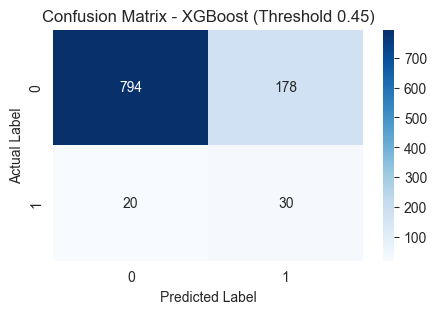

In [14]:
from xgboost import XGBClassifier

# Train and Evaluate XGBoost
print("Training XGBoost...")
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)
xgb_model.fit(X_train_res, y_train_res)
evaluate_and_plot(xgb_model, X_test, y_test, model_name="XGBoost", threshold=0.45)

### Logistic Regression

In [15]:
# Import the new functions
from src.preprocessing import apply_custom_encoding
from src.models import build_lr_pipeline
from src.evaluation import simulate_thresholds
from sklearn.metrics import accuracy_score # Ensure this is imported

X_train_enc, X_test_enc = apply_custom_encoding(X_train, X_test, y_train)

# Show the transformed data
X_train_enc.head(3)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,bmi_cat,age_cat,glucose_cat
845,0,48.0,0,0,1,0.049484,1,69.21,33.1,0.046711,3,3,0
3745,0,29.0,0,0,0,0.049484,1,84.19,21.2,0.046711,1,2,0
4184,0,35.0,0,0,1,0.049484,0,119.40,22.9,0.046711,1,2,1



--- THRESHOLD TUNING SIMULATION ---
Threshold  | Recall               | False Alarms (FP)   
-------------------------------------------------------
0.10       | 0.96                 | 629                 
0.20       | 0.86                 | 513                 
0.30       | 0.84                 | 412                 
0.40       | 0.84                 | 337                 
0.45       | 0.84                 | 293                 
0.50       | 0.80                 | 250                 

--- LOGISTIC REGRESSION (THRESHOLD 0.45) RESULTS ---
Recall (Stroke): 0.84
Overall Accuracy: 0.71

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.70      0.82       972
           1       0.13      0.84      0.22        50

    accuracy                           0.71      1022
   macro avg       0.56      0.77      0.52      1022
weighted avg       0.95      0.71      0.79      1022



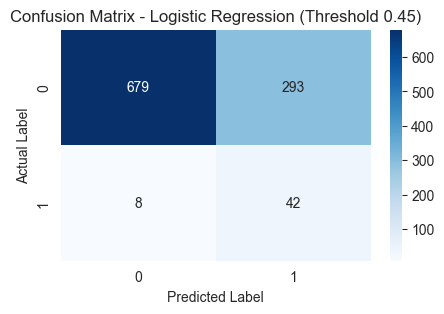

In [16]:
# Build and Train the Pipeline
lr_pipeline = build_lr_pipeline()
lr_pipeline.fit(X_train_enc, y_train)

# Evaluate at Threshold 0.45
y_probs = lr_pipeline.predict_proba(X_test_enc)[:, 1]
simulate_thresholds(y_test, y_probs, thresholds=[0.1, 0.2, 0.3, 0.4, 0.45, 0.5])

evaluate_and_plot(lr_pipeline, X_test_enc, y_test, model_name="Logistic Regression", threshold=0.45)

In [17]:
import joblib

X_train_enc, X_test_enc = apply_custom_encoding(
    X_train, X_test, y_train, 
    save_dir='app/model_artifacts'
)

lr_pipeline = build_lr_pipeline()
lr_pipeline.fit(X_train_enc, y_train)

joblib.dump(lr_pipeline, 'app/model_artifacts/lr_pipeline.pkl')

Đã lưu các encoders tại: app/model_artifacts


['app/model_artifacts/lr_pipeline.pkl']

### Visualize kết quả

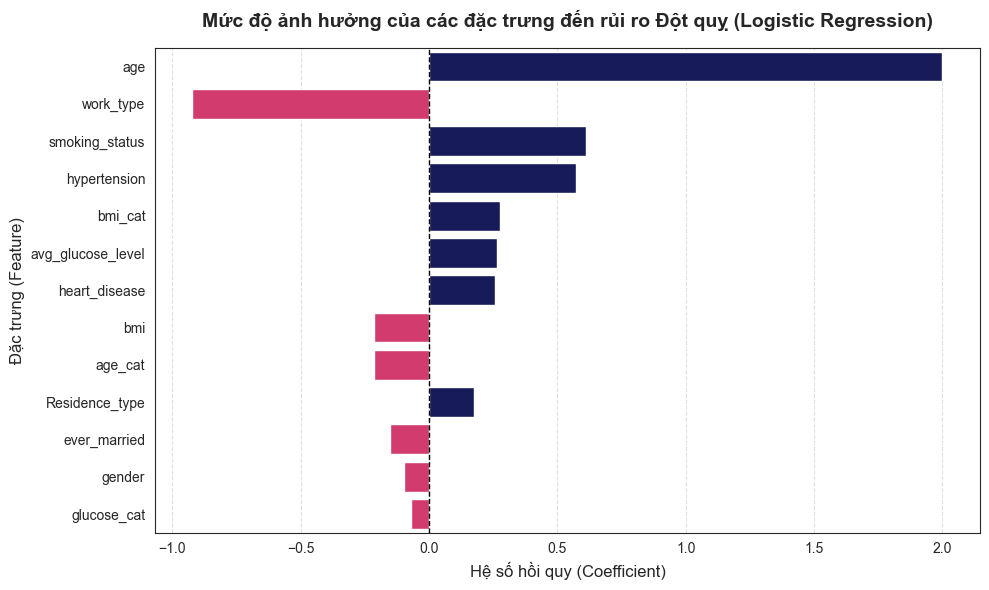

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Trích xuất mô hình và bộ tiền xử lý từ Pipeline
preprocessor = lr_pipeline.named_steps['preprocessor']
classifier = lr_pipeline.named_steps['classifier']

# 2. Lấy tên các đặc trưng sau khi đã đi qua preprocessor
feature_names = preprocessor.get_feature_names_out()

# 3. Lấy hệ số hồi quy (Coefficients) của Logistic Regression
coefficients = classifier.coef_[0]

# 4. Tạo DataFrame để dễ thao tác
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefficients,
    'Abs_Importance': abs(coefficients)
})

feature_importance = feature_importance.sort_values(by='Abs_Importance', ascending=False)
feature_importance['Feature'] = feature_importance['Feature'].apply(lambda x: x.split('__')[-1])

# 5. Vẽ biểu đồ Barplot bằng Seaborn
plt.figure(figsize=(10, 6))

colors = ['#EA2264' if val < 0 else '#0D1164' for val in feature_importance['Importance']]

sns.barplot(
    data=feature_importance, 
    x='Importance', 
    y='Feature', 
    palette=colors
)

plt.title('Mức độ ảnh hưởng của các đặc trưng đến rủi ro Đột quỵ (Logistic Regression)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hệ số hồi quy (Coefficient)', fontsize=12)
plt.ylabel('Đặc trưng (Feature)', fontsize=12)

# Thêm đường line số 0 để dễ nhìn
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

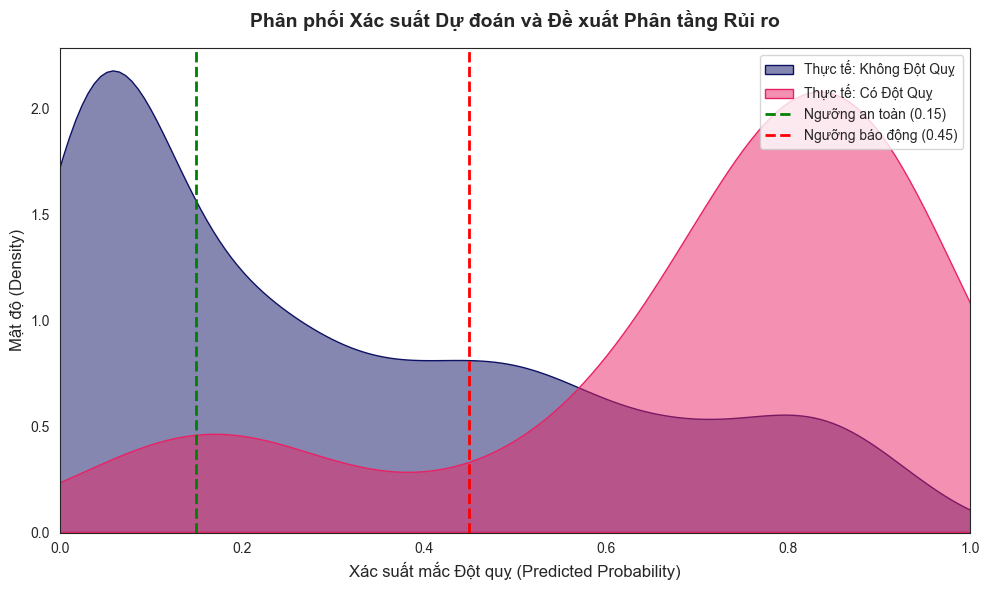

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

y_probs = lr_pipeline.predict_proba(X_test_enc)[:, 1]

plt.figure(figsize=(10, 6))

sns.kdeplot(y_probs[y_test == 0], color='#0D1164', fill=True, label='Thực tế: Không Đột Quỵ', alpha=0.5)

sns.kdeplot(y_probs[y_test == 1], color='#EA2264', fill=True, label='Thực tế: Có Đột Quỵ', alpha=0.5)

# Thêm các đường phân tầng rủi ro 
plt.axvline(x=0.15, color='green', linestyle='--', linewidth=2, label='Ngưỡng an toàn (0.15)')
plt.axvline(x=0.45, color='red', linestyle='--', linewidth=2, label='Ngưỡng báo động (0.45)')

plt.title('Phân phối Xác suất Dự đoán và Đề xuất Phân tầng Rủi ro', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Xác suất mắc Đột quỵ (Predicted Probability)', fontsize=12)
plt.ylabel('Mật độ (Density)', fontsize=12)
plt.legend(loc='upper right')
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import precision_score, recall_score, roc_curve, auc

# 1. TỔNG HỢP MÔ HÌNH VÀ DỮ LIỆU TƯƠNG ỨNG
models_dict = {
    "Stacking": (stacking_model, X_test),
    "Voting": (voting_model, X_test),
    "MLP": (mlp_model, X_test),
    "Random Forest": (rf_model, X_test),
    "XGBoost": (xgb_model, X_test),
    "Logistic Regression": (lr_pipeline, X_test_enc)
}

# Khởi tạo dictionary để lưu kết quả 
results = {
    "Model": [],
    "Precision (Stroke)": [], 
    "Recall (Stroke)": [],
    "FPR": [],
    "TPR": [],
    "AUC": []
}

THRESHOLD = 0.45

# 2. TÍNH TOÁN METRICS CHO TỪNG MÔ HÌNH
for name, (model, X_data) in models_dict.items():
    # Lấy xác suất dự đoán cho Class 1 (Stroke)
    y_probs = model.predict_proba(X_data)[:, 1]
    
    y_pred_custom = (y_probs >= THRESHOLD).astype(int)
    
    # TÍNH PRECISION VÀ RECALL CHO LỚP 1
    prec = precision_score(y_test, y_pred_custom, pos_label=1, zero_division=0)
    rec = recall_score(y_test, y_pred_custom, pos_label=1)
    
    # Tính ROC và AUC 
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    
    # Lưu vào dictionary
    results["Model"].append(name)
    results["Precision (Stroke)"].append(prec)
    results["Recall (Stroke)"].append(rec)
    results["FPR"].append(fpr)
    results["TPR"].append(tpr)
    results["AUC"].append(roc_auc)

sns.set_theme(style="whitegrid")

base_colors = ['#0D1164', '#640D5F', '#EA2264', '#F78D60']

custom_cmap = LinearSegmentedColormap.from_list("custom_palette", base_colors)
num_models = len(results["Model"])
custom_line_colors = [custom_cmap(i) for i in np.linspace(0, 1, num_models)]


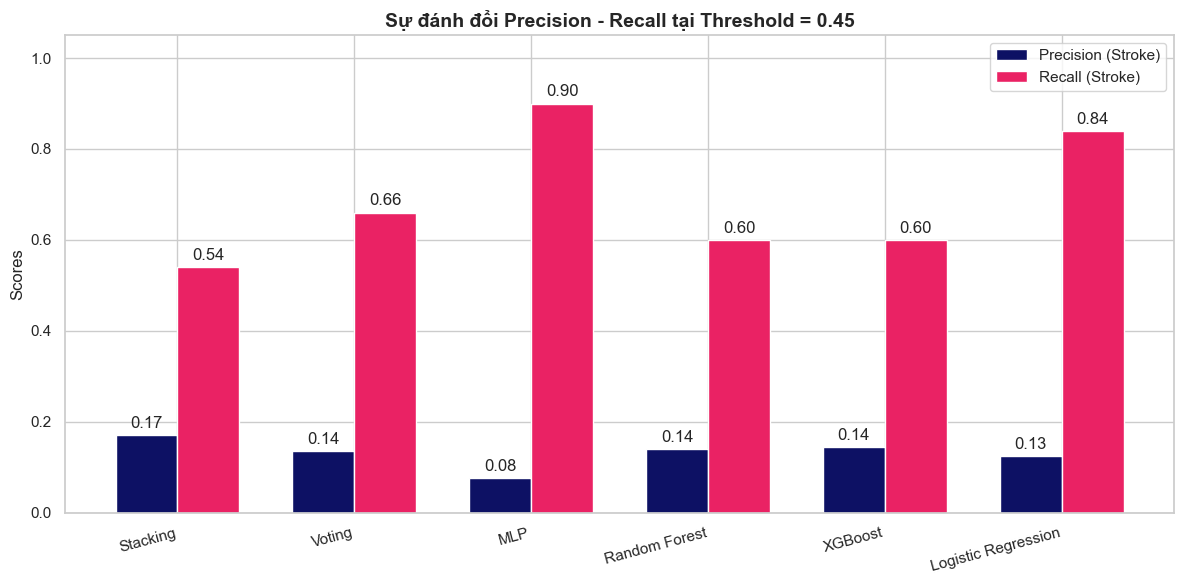

In [21]:
# ---------------------------------------------------------
# VISUALIZATION 1: GROUPED BAR CHART (PRECISION VS RECALL)
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results["Model"]))  
width = 0.35 

color_prec = '#0D1164'
color_rec = '#EA2264'

rects1 = ax.bar(x - width/2, results["Precision (Stroke)"], width, label='Precision (Stroke)', color=color_prec)
rects2 = ax.bar(x + width/2, results["Recall (Stroke)"], width, label='Recall (Stroke)', color=color_rec)

ax.set_ylabel('Scores', fontsize=12)
ax.set_title(f'Sự đánh đổi Precision - Recall tại Threshold = {THRESHOLD}', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results["Model"], rotation=15, ha="right", fontsize=11)
ax.legend(loc='upper right') 

ax.bar_label(rects1, fmt='%.2f', padding=3)
ax.bar_label(rects2, fmt='%.2f', padding=3)

ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

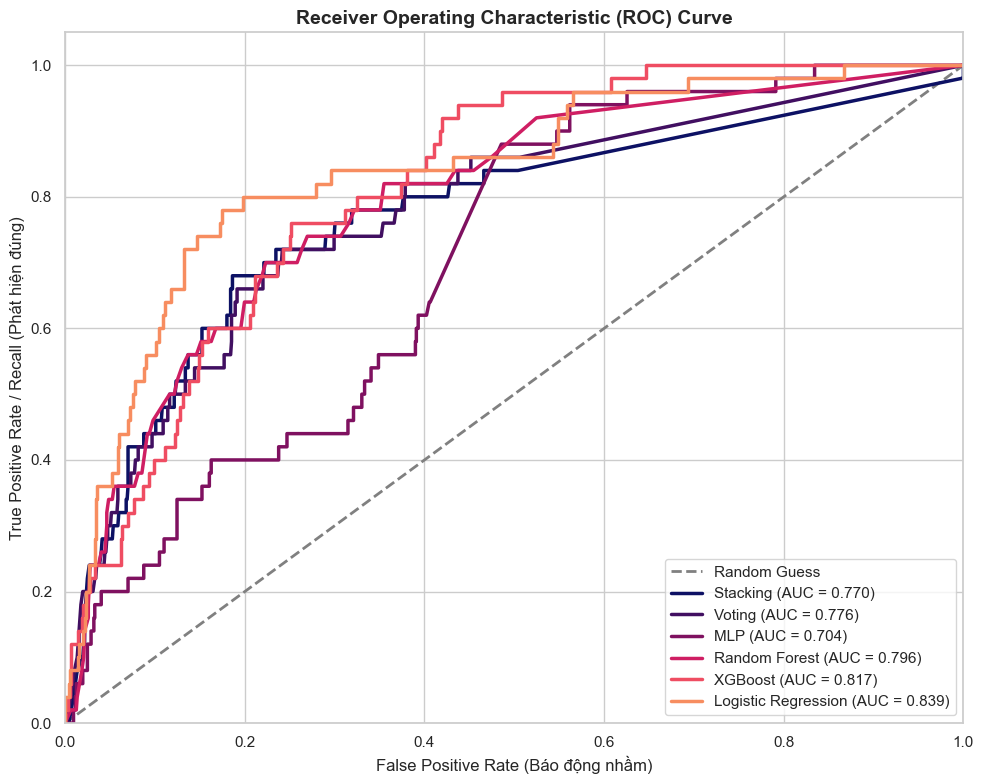

In [22]:
# ---------------------------------------------------------
# VISUALIZATION 2: ROC CURVE & AUC
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess')

for i in range(num_models):
    plt.plot(results["FPR"][i], results["TPR"][i], color=custom_line_colors[i], lw=2.5, 
             label=f'{results["Model"][i]} (AUC = {results["AUC"][i]:.3f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Báo động nhầm)', fontsize=12)
plt.ylabel('True Positive Rate / Recall (Phát hiện đúng)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)

plt.tight_layout()
plt.show()

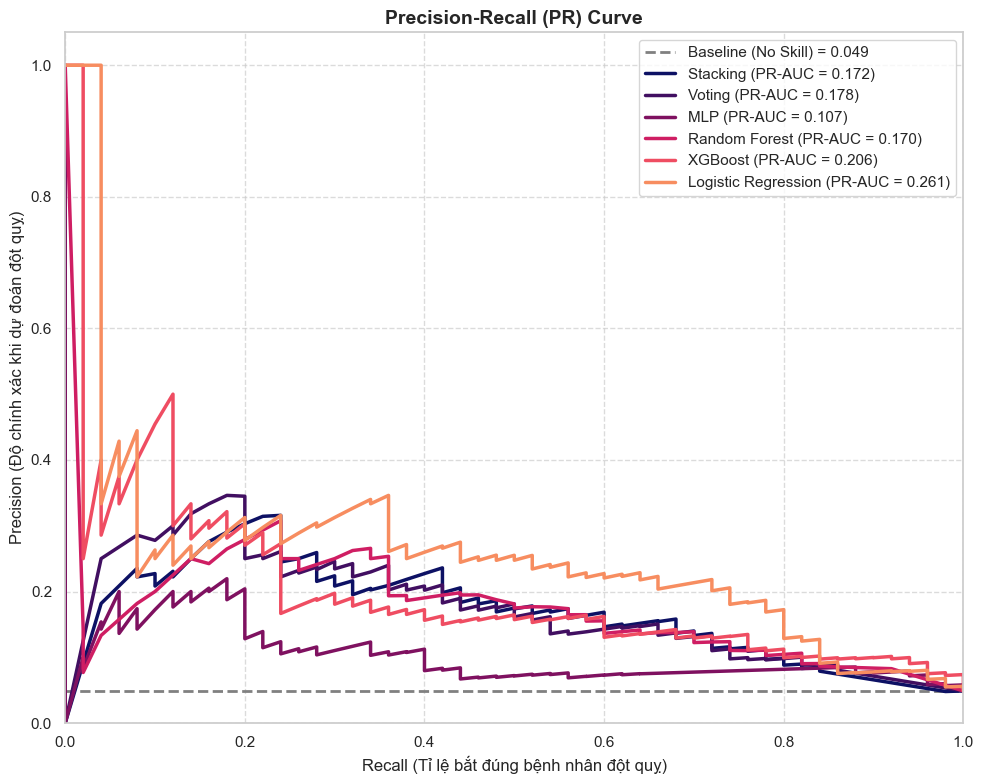

In [23]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# ---------------------------------------------------------
# VISUALIZATION 3: PRECISION-RECALL (PR) CURVE
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))

baseline = y_test.sum() / len(y_test)
plt.plot([0, 1], [baseline, baseline], color='gray', lw=2, linestyle='--', 
         label=f'Baseline (No Skill) = {baseline:.3f}')

for i, (name, (model, X_data)) in enumerate(models_dict.items()):
    y_probs = model.predict_proba(X_data)[:, 1]
    
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    pr_auc = average_precision_score(y_test, y_probs)
    
    plt.plot(recall, precision, color=custom_line_colors[i], lw=2.5, 
             label=f'{name} (PR-AUC = {pr_auc:.3f})')

# Trang trí biểu đồ
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (Tỉ lệ bắt đúng bệnh nhân đột quỵ)', fontsize=12)
plt.ylabel('Precision (Độ chính xác khi dự đoán đột quỵ)', fontsize=12)
plt.title('Precision-Recall (PR) Curve', fontsize=14, fontweight='bold')

plt.legend(loc="upper right", fontsize=11) 
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()